# Лабораторная работа № 1.1
## Статистические ряды распределения

**Выполнили:**

- Левченков Артемий Викторович;
- Бикбулатова Динара Фануровна;
- Ладыгин Максим Александрович.

**Группа:** БИВТ-24-АЭ-3

Исходные данные - статистика преступлений, совершённых в Москве в 2021 году, распределённых по возрасту преступников.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_table("/Users/blx000/PycharmProjects/matstat/data/moscow.txt", header=None)[0]
N = len(data)

print("Количество наблюдений:", N)
print("Минимальный возраст:", data.min())
print("Максимальный возраст:", data.max())

Количество наблюдений: 32423
Минимальный возраст: 14
Максимальный возраст: 73


### 1. Дискретный и интервальный ряды распределения

In [13]:
discrete = data.value_counts().sort_index().rename_axis("x").reset_index(name="n")
discrete["w"] = discrete["n"] / N

print("Дискретный ряд")
display(discrete)

Дискретный ряд


,x,n,w
0,14,49,0.001511
1,15,53,0.001635
2,16,236,0.007279
3,17,126,0.003886
4,18,806,0.024859
5,19,971,0.029948
6,20,910,0.028066
7,21,716,0.022083
8,22,944,0.029115
9,23,1071,0.033032


In [6]:
k = 7
x_min = data.min()
x_max = data.max()
h = (x_max - x_min) / k
edges = [x_min + i * h for i in range(k + 1)]

rows = []
for i in range(k):
    left = edges[i]
    right = edges[i + 1]

    if i < k - 1:
        n = ((data >= left) & (data < right)).sum()
    else:
        n = ((data >= left) & (data <= right)).sum()

    rows.append([left, right, (left + right) / 2, n])

interval = pd.DataFrame(rows, columns=["x_l", "x_r", "x_middle", "n"])
interval["w"] = interval["n"] / N
interval["S"] = interval["n"].cumsum()

print(f"Ширина интервала: h = ({x_max} - {x_min}) / {k} = {h:.4f}")
display(interval.round(4))

Ширина интервала: h = (73 - 14) / 7 = 8.4286


,x_l,x_r,x_middle,n,w,S
0,14.0000,22.4286,18.2143,4811,0.1484,4811
1,22.4286,30.8571,26.6429,8361,0.2579,13172
2,30.8571,39.2857,35.0714,7635,0.2355,20807
3,39.2857,47.7143,43.5000,6588,0.2032,27395
4,47.7143,56.1429,51.9286,2828,0.0872,30223
5,56.1429,64.5714,60.3571,1475,0.0455,31698
6,64.5714,73.0000,68.7857,725,0.0224,32423


### 2. Статистические характеристики

\[
\bar{x}=\frac{\sum x_i n_i}{N}, \qquad
D=\frac{\sum (x_i-\bar{x})^2n_i}{N}, \qquad
\sigma=\sqrt{D}, \qquad
V=\frac{\sigma}{\bar{x}}\cdot100\%.
\]

In [7]:
def mean_value(x, n):
    return sum(x * n) / sum(n)


def dispersion(x, n, mean):
    return sum((x - mean) ** 2 * n) / sum(n)


def standard_deviation(D):
    return D ** 0.5


def coefficient_of_variation(sigma, mean):
    return sigma / mean * 100


def minimum(x):
    return min(x)


def maximum(x):
    return max(x)


def range_value(x):
    return maximum(x) - minimum(x)


def discrete_mode(x, n):
    i = n.idxmax()
    return x[i], n[i]


def discrete_median(data):
    return data.median()


def interval_mode(interval):
    i = interval["n"].idxmax()
    L = interval.loc[i, "x_l"]
    h = interval.loc[i, "x_r"] - L
    n_i = interval.loc[i, "n"]
    n_prev = interval.loc[i - 1, "n"] if i > 0 else 0
    n_next = interval.loc[i + 1, "n"] if i < len(interval) - 1 else 0

    Mo = L + h * (n_i - n_prev) / ((n_i - n_prev) + (n_i - n_next))
    return Mo, n_i


def interval_median(interval, N):
    i = interval[interval["S"] >= N / 2].index[0]
    L = interval.loc[i, "x_l"]
    h = interval.loc[i, "x_r"] - L
    n_i = interval.loc[i, "n"]
    S_prev = interval.loc[i - 1, "S"] if i > 0 else 0

    return L + h * (N / 2 - S_prev) / n_i


def print_result(mean, D, sigma, V, Mo, mode_frequency, Me, x_min, x_max, R):
    print(f"Средняя: {mean:.4f}")
    print(f"Дисперсия: {D:.4f}")
    print(f"Среднее квадратическое отклонение: {sigma:.4f}")
    print(f"Коэффициент вариации: {V:.4f}%")
    print(f"Мода: {Mo:.4f}")
    print(f"Частота моды: {mode_frequency}")
    print(f"Медиана: {Me:.4f}")
    print(f"Минимальное значение: {x_min:.4f}")
    print(f"Максимальное значение: {x_max:.4f}")
    print(f"Размах: {R:.4f}")

#### Дискретный ряд

In [8]:
x = discrete["x"]
n = discrete["n"]

mean_d = mean_value(x, n)
D_d = dispersion(x, n, mean_d)
sigma_d = standard_deviation(D_d)
V_d = coefficient_of_variation(sigma_d, mean_d)
Mo_d, mode_frequency_d = discrete_mode(x, n)
Me_d = discrete_median(data)
min_d = minimum(x)
max_d = maximum(x)
R_d = range_value(x)

print_result(mean_d, D_d, sigma_d, V_d, Mo_d, mode_frequency_d,
             Me_d, min_d, max_d, R_d)

Средняя: 35.3730
Дисперсия: 144.9170
Среднее квадратическое отклонение: 12.0381
Коэффициент вариации: 34.0320%
Мода: 29.0000
Частота моды: 1340
Медиана: 34.0000
Минимальное значение: 14.0000
Максимальное значение: 73.0000
Размах: 59.0000


#### Интервальный ряд

In [9]:
x = interval["x_middle"]
n = interval["n"]

mean_i = mean_value(x, n)
D_i = dispersion(x, n, mean_i)
sigma_i = standard_deviation(D_i)
V_i = coefficient_of_variation(sigma_i, mean_i)
Mo_i, mode_frequency_i = interval_mode(interval)
Me_i = interval_median(interval, N)
min_i = minimum(interval["x_l"])
max_i = maximum(interval["x_r"])
R_i = max_i - min_i

print_result(mean_i, D_i, sigma_i, V_i, Mo_i, mode_frequency_i,
             Me_i, min_i, max_i, R_i)

Средняя: 35.4837
Дисперсия: 154.0370
Среднее квадратическое отклонение: 12.4112
Коэффициент вариации: 34.9771%
Мода: 29.4261
Частота моды: 8361
Медиана: 34.2126
Минимальное значение: 14.0000
Максимальное значение: 73.0000
Размах: 59.0000


### 3. Полигон и гистограмма частот

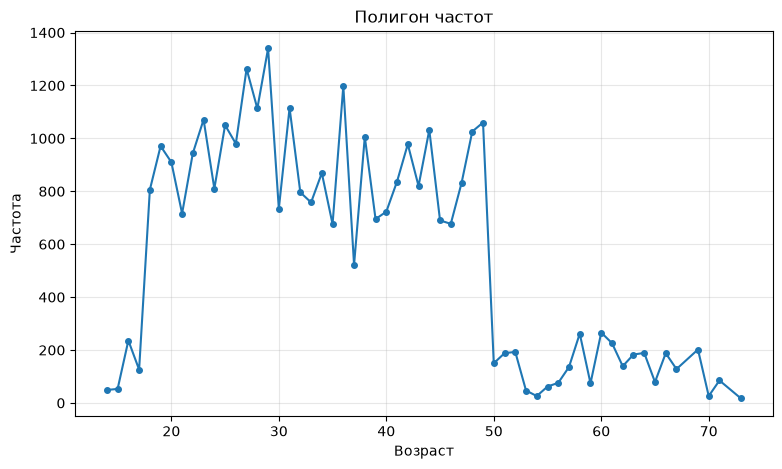

In [10]:
plt.figure(figsize=(9, 5))
plt.plot(discrete["x"], discrete["n"], marker="o", markersize=4)
plt.title("Полигон частот")
plt.xlabel("Возраст")
plt.ylabel("Частота")
plt.grid(alpha=0.3)
plt.show()

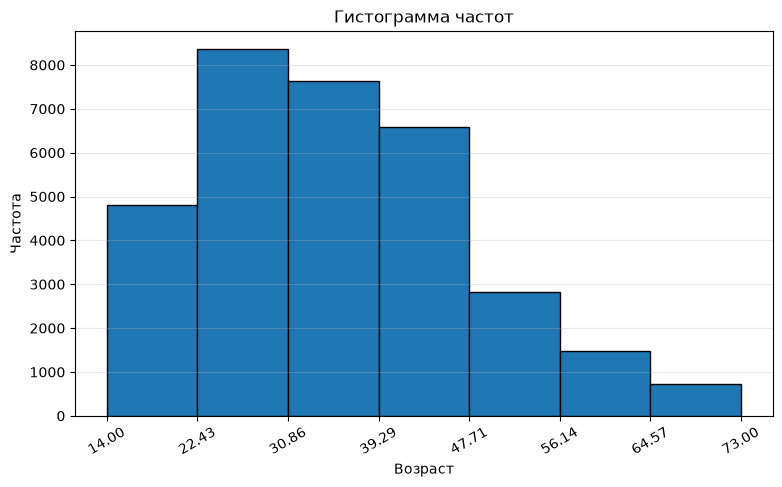

In [11]:
plt.figure(figsize=(9, 5))
plt.bar(interval["x_l"], interval["n"], width=h, align="edge", edgecolor="black")
plt.title("Гистограмма частот")
plt.xlabel("Возраст")
plt.ylabel("Частота")
plt.xticks(edges, [f"{edge:.2f}" for edge in edges], rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()